# MIRA & TARP Analysis — SigmaDock vs DiffDock (PoseBusters)

Evaluates and compares the **pose distribution calibration** of SigmaDock and DiffDock using:

- **MIRA** (Sharief et al. 2026): posterior calibration score. `mira_null(S=40) ≈ 0.683` = perfect. Below = mode-collapsed, above = over-dispersed.
- **TARP** (Lemos et al. 2023): Expected Coverage Probability (ECP) curve — purely qualitative. ECP above diagonal = over-dispersed; below = mode-collapsed.

Both models evaluated on the **PoseBusters benchmark** with S=40 pose samples per complex.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

from molcalib.tarp import ecp_from_fractions, bootstrap_ecp, plot_ecp
from molcalib.mira import mira_null, bootstrap_mira

MIRA_REF = mira_null(40)
print(f'MIRA reference (S=40): {MIRA_REF:.4f}')

SD_RESULTS  = '/home/qf226/rds/hpc-work/results/SigmaDock/sigmadock_pb_308'
DD_METRICS  = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics'

FIGDIR = '../figures/sigmadock'
os.makedirs(FIGDIR, exist_ok=True)

MIRA reference (S=40): 0.6833


## 0. Accuracy

Docking accuracy on the PoseBusters benchmark (S=40 poses per complex).

- **Top-1**: % of complexes where the top-ranked pose has RMSD < 2 Å to the crystal.
- **Top-1 + PB-valid**: same pose also passes all PoseBusters physicochemical checks.
- **Oracle**: % of complexes where the *best* of 40 poses has RMSD < 2 Å — upper bound at this sample count.

SigmaDock uses ODE sampling (25 steps) with the paper heuristic ranking (−Affinity × pb_mean⁴); DiffDock uses SDE (20 steps) with its confidence model.

In [2]:
import json

SD_C = '#2196F3'   # SigmaDock blue
DD_C = '#FF5722'   # DiffDock orange

# SigmaDock accuracy metrics (ODE-25, heuristic ranking: -Affinity × pb_mean^4)
_SD_ACC = '/home/qf226/rds/hpc-work/results/SigmaDock/sigmadock_pb_sde/results/posebusters/ode_25/metrics'
sd_acc_top1  = np.load(f'{_SD_ACC}/top1_rmsd.npy')    # (307,) top-ranked pose RMSD
sd_acc_rmsds = np.load(f'{_SD_ACC}/rmsds.npy')         # (307, 40) all-pose RMSDs
with open(f'{_SD_ACC}/posebusters_results_pb.json') as _f:
    sd_acc_pb = json.load(_f)

# DiffDock accuracy metrics (SDE-20, confidence ranking)
dd_acc_top1  = np.load(f'{DD_METRICS}/top1_rmsd.npy')  # (305,) top-ranked pose RMSD
dd_acc_rmsds = np.load(f'{DD_METRICS}/rmsds.npy')       # (305, 40) all-pose RMSDs
with open(f'{DD_METRICS}/posebusters_results_pb.json') as _f:
    dd_acc_pb = json.load(_f)

# ── Compute accuracy metrics ───────────────────────────────────────────────────
# SigmaDock pb json: key = 'XXXX::XXXX_ligands', rank1 key = 'rank1'
sd_pb_pass1 = np.array(['rank1' in v['valid_ranks'] for v in sd_acc_pb.values()])
sd_top1_acc = (sd_acc_top1 < 2).mean()
sd_pb_acc   = (sd_pb_pass1 & (sd_acc_top1 < 2)).mean()
sd_oracle   = (sd_acc_rmsds.min(axis=1) < 2).mean()

# DiffDock pb json: key = 'XXXX', rank1 key = 'rank1.sdf'
# Align by complex_names.npy — JSON dict order differs from npy order
dd_names    = np.load(f'{DD_METRICS}/complex_names.npy', allow_pickle=True)
dd_pb_pass1 = np.array(['rank1.sdf' in dd_acc_pb.get(n, {}).get('valid_ranks', []) for n in dd_names])
dd_top1_acc = (dd_acc_top1 < 2).mean()
dd_pb_acc   = (dd_pb_pass1 & (dd_acc_top1 < 2)).mean()
dd_oracle   = (dd_acc_rmsds.min(axis=1) < 2).mean()

print(f'SigmaDock ODE-25 (N={len(sd_acc_top1)}):')
print(f'  Top-1:         {sd_top1_acc:.1%}')
print(f'  Top-1+PB:      {sd_pb_acc:.1%}')
print(f'  Oracle (S=40): {sd_oracle:.1%}')
print(f'DiffDock SDE-20 (N={len(dd_acc_top1)}):')
print(f'  Top-1:         {dd_top1_acc:.1%}')
print(f'  Top-1+PB:      {dd_pb_acc:.1%}')
print(f'  Oracle (S=40): {dd_oracle:.1%}')

SigmaDock ODE-25 (N=307):
  Top-1:         81.1%
  Top-1+PB:      77.9%
  Oracle (S=40): 93.5%
DiffDock SDE-20 (N=305):
  Top-1:         52.8%
  Top-1+PB:      27.2%
  Oracle (S=40): 61.6%


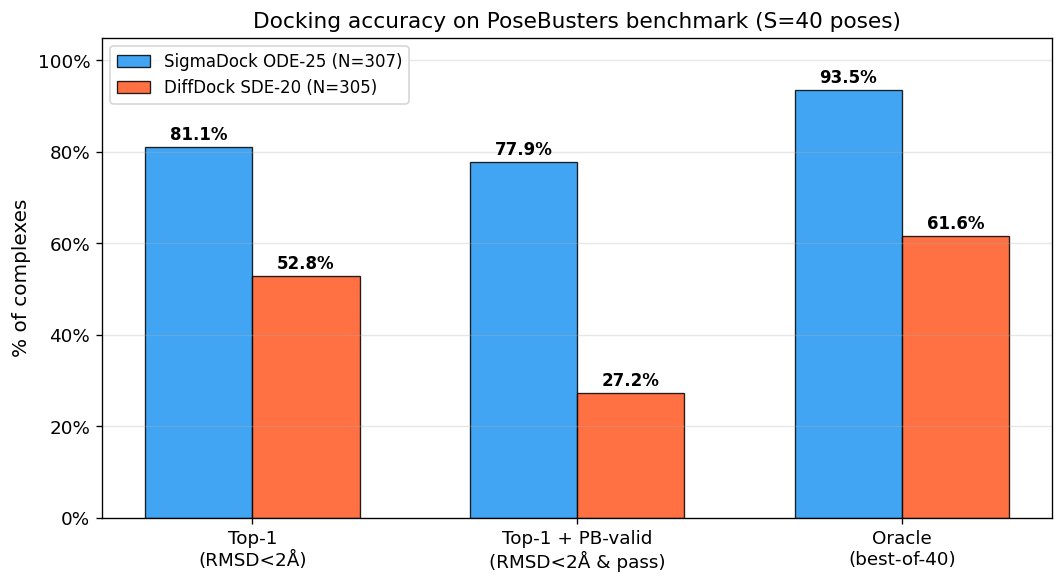

In [3]:
METRICS = ['Top-1\n(RMSD<2Å)', 'Top-1 + PB-valid\n(RMSD<2Å & pass)', 'Oracle\n(best-of-40)']
sd_vals = [sd_top1_acc, sd_pb_acc, sd_oracle]
dd_vals = [dd_top1_acc, dd_pb_acc, dd_oracle]

x = np.arange(len(METRICS))
w = 0.33

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [v*100 for v in sd_vals], w, color=SD_C, alpha=0.85, edgecolor='k', lw=0.8,
            label=f'SigmaDock ODE-25 (N={len(sd_acc_top1)})')
b2 = ax.bar(x + w/2, [v*100 for v in dd_vals], w, color=DD_C, alpha=0.85, edgecolor='k', lw=0.8,
            label=f'DiffDock SDE-20 (N={len(dd_acc_top1)})')

for bars, vals in [(b1, sd_vals), (b2, dd_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(METRICS, fontsize=11)
ax.set_ylabel('% of complexes', fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('Docking accuracy on PoseBusters benchmark (S=40 poses)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, pos: f'{v:.0f}%'))
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 1. Load data

In [4]:
# ── SigmaDock ─────────────────────────────────────────────────────────────────
sd_centroid = np.load(f'{SD_RESULTS}/mira_tarp.npz', allow_pickle=True)
sd_mira_scores   = sd_centroid['mira_scores']       # (308,)
sd_tarp_centroid = sd_centroid['tarp_f_matrix']     # (308, 100)

# RMSD TARP — computed separately (mira_tarp_rmsd.sh); falls back to centroid if not ready
_rmsd_path = f'{SD_RESULTS}/mira_tarp_rmsd.npz'
if os.path.exists(_rmsd_path):
    sd_rmsd = np.load(_rmsd_path, allow_pickle=True)
    sd_tarp_rmsd = sd_rmsd['tarp_f_matrix']         # (308, 10)
    print(f'SigmaDock RMSD TARP loaded: {sd_tarp_rmsd.shape}')
else:
    sd_tarp_rmsd = None
    print('SigmaDock RMSD TARP not yet computed — RMSD plots will use centroid fractions.')

# ── DiffDock (PoseBusters) ────────────────────────────────────────────────────
dd_mira_scores   = np.load(f'{DD_METRICS}/mira_scores_symrmsd.npy')           # (303,)  RMSD metric
dd_tarp_centroid = np.load(f'{DD_METRICS}/tarp_fractions_centroid.npy')    # (303, 100)
dd_tarp_rmsd     = np.load(f'{DD_METRICS}/tarp_fractions_symrmsd_K10.npy')     # (303, 1)

print(f'SigmaDock  N={len(sd_mira_scores)} complexes  MIRA mean={sd_mira_scores.mean():.4f}')
print(f'DiffDock   N={len(dd_mira_scores)} complexes  MIRA mean={dd_mira_scores.mean():.4f}')
print(f'Reference  MIRA={MIRA_REF:.4f}')

SigmaDock RMSD TARP loaded: (308, 10)
SigmaDock  N=308 complexes  MIRA mean=0.6548
DiffDock   N=305 complexes  MIRA mean=0.6326
Reference  MIRA=0.6833


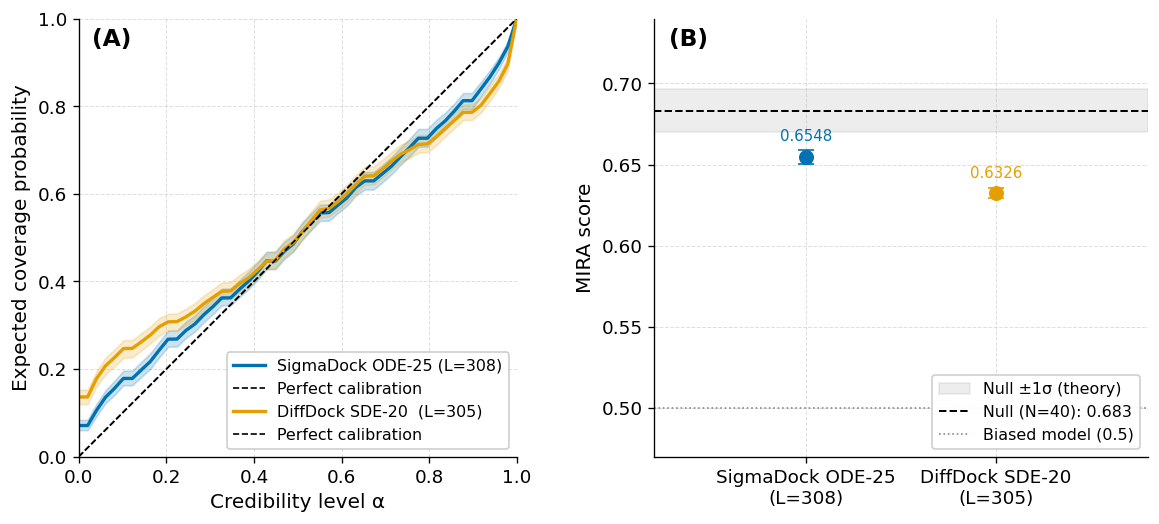

In [5]:
# ── TARP + MIRA (symRMSD) — main text figure ─────────────────────────────────
from molcalib.style import setup, C, FS, subfig_label
setup()

NULL   = mira_null(40)
BIASED = 0.5
YLIM   = (0.47, 0.74)

sd_mira_symrmsd = sd_rmsd['mira_scores']   # (308,)  symRMSD MIRA
SIGMA = (1 / (18 * min(np.isfinite(sd_mira_symrmsd).sum(),
                        np.isfinite(dd_mira_scores).sum()))) ** 0.5

def _dot(ax, x, sc, color):
    sc = sc[np.isfinite(sc)]
    b  = bootstrap_mira(sc)
    ax.errorbar(x, b['mean'], yerr=b['std'], fmt='o',
                color=color, capsize=5, ms=8, lw=1.5, zorder=5)
    ax.text(x, b['mean'] + b['std'] + 0.004, f'{b["mean"]:.4f}',
            ha='center', va='bottom', fontsize=FS['ann'] - 1, color=color)

rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ── (A) TARP ECP — symRMSD, K=10 ─────────────────────────────────────────────
ax = axes[0]
for f, col, lbl in [
    (sd_tarp_rmsd, C['blue'],   f'SigmaDock ODE-25 (L={len(sd_tarp_rmsd)})'),
    (dd_tarp_rmsd, C['orange'], f'DiffDock SDE-20  (L={len(dd_tarp_rmsd)})'),
]:
    ecp, alpha = ecp_from_fractions(f)
    boot = bootstrap_ecp(f, n_bootstrap=500, rng=rng)
    plot_ecp(ecp, alpha, ax=ax, label=lbl, color=col, bootstrap_ecps=boot)
ax.legend(fontsize=FS['legend'])
subfig_label(ax, 'A')

# ── (B) MIRA scores — symRMSD ────────────────────────────────────────────────
ax = axes[1]
ax.axhspan(NULL - SIGMA, NULL + SIGMA, alpha=0.15, color=C['grey'], zorder=0,
           label='Null ±1σ (theory)')
ax.axhline(NULL,   color='k',       ls='--', lw=1.2, zorder=1,
           label=f'Null (N=40): {NULL:.3f}')
ax.axhline(BIASED, color=C['grey'], ls=':',  lw=1.0, zorder=1,
           label='Biased model (0.5)')
for x, sc, col in [
    (0, sd_mira_symrmsd, C['blue']),
    (1, dd_mira_scores,  C['orange']),
]:
    _dot(ax, x, sc, col)
ax.set_xticks([0, 1])
ax.set_xticklabels(
    [f'SigmaDock ODE-25\n(L={int(np.isfinite(sd_mira_symrmsd).sum())})',
     f'DiffDock SDE-20\n(L={int(np.isfinite(dd_mira_scores).sum())})'],
    fontsize=FS['tick'],
)
ax.set_xlim(-0.8, 1.8)
ax.set_ylim(*YLIM)
ax.set_ylabel('MIRA score', fontsize=FS['label'])
ax.legend(fontsize=FS['legend'], loc='lower right')
subfig_label(ax, 'B')

fig.tight_layout()
fig.savefig(f'{FIGDIR}/tarp_mira_symrmsd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. TARP — SigmaDock (centroid + RMSD)

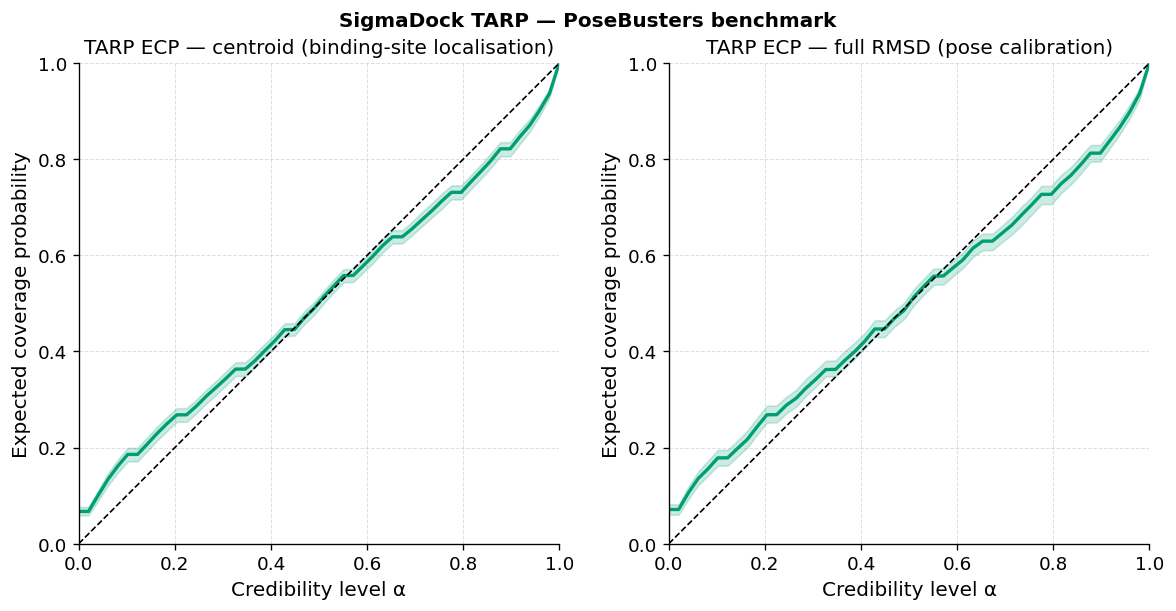

In [6]:
sd_ecp_c, sd_alpha_c = ecp_from_fractions(sd_tarp_centroid)
sd_boot_c = bootstrap_ecp(sd_tarp_centroid, n_bootstrap=200)

ncols = 2 if sd_tarp_rmsd is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
if ncols == 1:
    axes = [axes]

plot_ecp(sd_ecp_c, sd_alpha_c, ax=axes[0],
         label=f'SigmaDock (N={len(sd_mira_scores)}, K=100)',
         color='C0', bootstrap_ecps=sd_boot_c)
axes[0].set_title('TARP ECP — centroid (binding-site localisation)')

if sd_tarp_rmsd is not None:
    sd_ecp_r, sd_alpha_r = ecp_from_fractions(sd_tarp_rmsd)
    sd_boot_r = bootstrap_ecp(sd_tarp_rmsd, n_bootstrap=200)
    plot_ecp(sd_ecp_r, sd_alpha_r, ax=axes[1],
             label=f'SigmaDock (N={sd_tarp_rmsd.shape[0]}, K={sd_tarp_rmsd.shape[1]})',
             color='C0', bootstrap_ecps=sd_boot_r)
    axes[1].set_title('TARP ECP — full RMSD (pose calibration)')

fig.suptitle('SigmaDock TARP — PoseBusters benchmark', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/tarp_sigmadock.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. TARP — SigmaDock vs DiffDock comparison

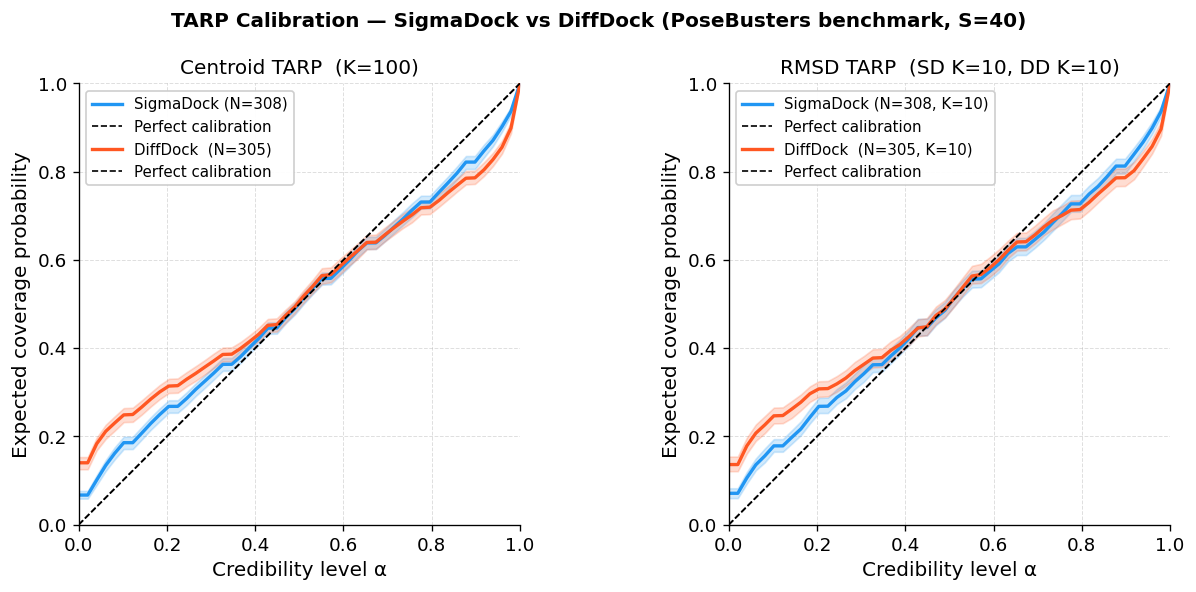

In [7]:
SD_C = '#2196F3'
DD_C = '#FF5722'

dd_ecp_c, dd_alpha_c = ecp_from_fractions(dd_tarp_centroid)
dd_boot_c = bootstrap_ecp(dd_tarp_centroid, n_bootstrap=200)

dd_ecp_r, dd_alpha_r = ecp_from_fractions(dd_tarp_rmsd)
dd_boot_r = bootstrap_ecp(dd_tarp_rmsd, n_bootstrap=200)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ── Centroid (K=100 both) ─────────────────────────────────────────────────────
ax = axes[0]
plot_ecp(sd_ecp_c, sd_alpha_c, ax=ax,
         label=f'SigmaDock (N={len(sd_mira_scores)})', color=SD_C, bootstrap_ecps=sd_boot_c)
plot_ecp(dd_ecp_c, dd_alpha_c, ax=ax,
         label=f'DiffDock  (N={len(dd_mira_scores)})', color=DD_C, bootstrap_ecps=dd_boot_c)
ax.set_title('Centroid TARP  (K=100)')
ax.legend(fontsize=9)

# ── RMSD ─────────────────────────────────────────────────────────────────────
ax = axes[1]
if sd_tarp_rmsd is not None:
    sd_ecp_r, sd_alpha_r = ecp_from_fractions(sd_tarp_rmsd)
    sd_boot_r = bootstrap_ecp(sd_tarp_rmsd, n_bootstrap=200)
    plot_ecp(sd_ecp_r, sd_alpha_r, ax=ax,
             label=f'SigmaDock (N={sd_tarp_rmsd.shape[0]}, K={sd_tarp_rmsd.shape[1]})',
             color=SD_C, bootstrap_ecps=sd_boot_r)
else:
    ax.text(0.5, 0.5, 'RMSD TARP\nnot yet computed\n(job 30099162 running)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11)

plot_ecp(dd_ecp_r, dd_alpha_r, ax=ax,
         label=f'DiffDock  (N={len(dd_mira_scores)}, K={dd_tarp_rmsd.shape[1]})',
         color=DD_C, bootstrap_ecps=dd_boot_r)
ax.set_title(f'RMSD TARP  (SD K={sd_tarp_rmsd.shape[1] if sd_tarp_rmsd is not None else "—"}, DD K={dd_tarp_rmsd.shape[1]})')
ax.legend(fontsize=9)

fig.suptitle('TARP Calibration — SigmaDock vs DiffDock (PoseBusters benchmark, S=40)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/tarp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. MIRA — SigmaDock distribution

Violin + histogram matching DiffDock notebook style.

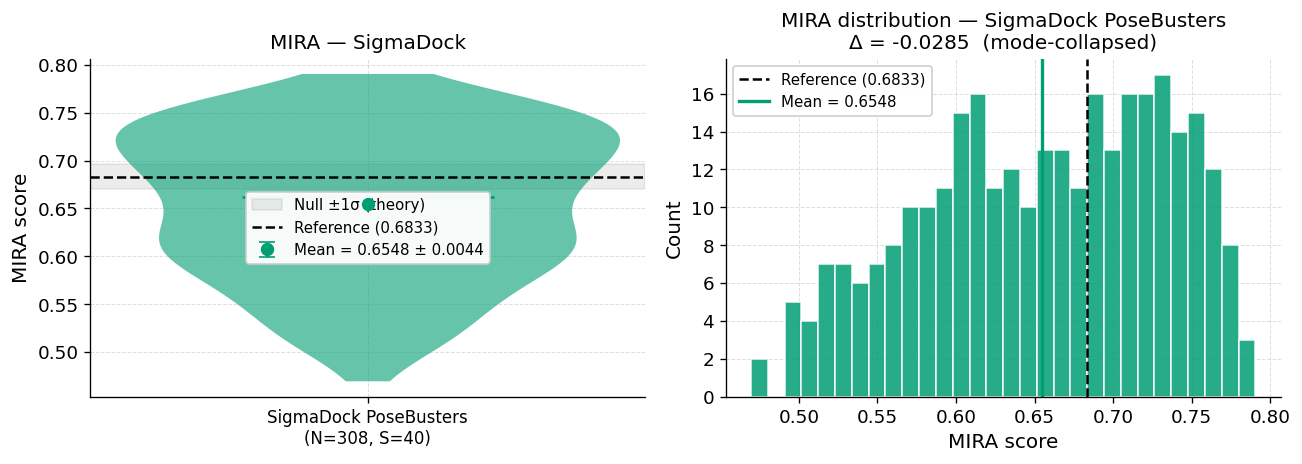

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: violin ──────────────────────────────────────────────────────────────
ax = axes[0]
vp = ax.violinplot([sd_mira_scores], positions=[0], showmedians=True, showextrema=False)
vp['bodies'][0].set_facecolor('C0'); vp['bodies'][0].set_alpha(0.6)
_boot = bootstrap_mira(sd_mira_scores)
se = _boot['std']
ax.errorbar(0, sd_mira_scores.mean(), yerr=se, fmt='o', color='C0', capsize=5, ms=7, zorder=5,
            label=f'Mean = {sd_mira_scores.mean():.4f} ± {se:.4f}')
_sigma_null = np.sqrt(1 / (18 * len(sd_mira_scores)))
ax.axhspan(MIRA_REF - _sigma_null, MIRA_REF + _sigma_null,
           alpha=0.15, color='grey', zorder=0, label=f'Null ±1σ (theory)')
ax.axhline(MIRA_REF, color='k', lw=1.5, ls='--', label=f'Reference ({MIRA_REF:.4f})')
ax.set_xticks([0])
ax.set_xticklabels([f'SigmaDock PoseBusters\n(N={len(sd_mira_scores)}, S=40)'], fontsize=10)
ax.set_ylabel('MIRA score')
ax.set_title('MIRA — SigmaDock')
ax.legend(fontsize=9)

# ── Right: histogram ──────────────────────────────────────────────────────────
ax = axes[1]
ax.hist(sd_mira_scores, bins=30, color='C0', edgecolor='white', alpha=0.85)
ax.axvline(MIRA_REF, color='k', lw=1.5, ls='--', label=f'Reference ({MIRA_REF:.4f})')
ax.axvline(sd_mira_scores.mean(), color='C0', lw=2,
           label=f'Mean = {sd_mira_scores.mean():.4f}')
delta = sd_mira_scores.mean() - MIRA_REF
direction = 'mode-collapsed' if delta < 0 else 'over-dispersed'
ax.set_xlabel('MIRA score')
ax.set_ylabel('Count')
ax.set_title(f'MIRA distribution — SigmaDock PoseBusters\n'
             f'Δ = {delta:+.4f}  ({direction})')
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/mira_sigmadock.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. MIRA — SigmaDock vs DiffDock comparison

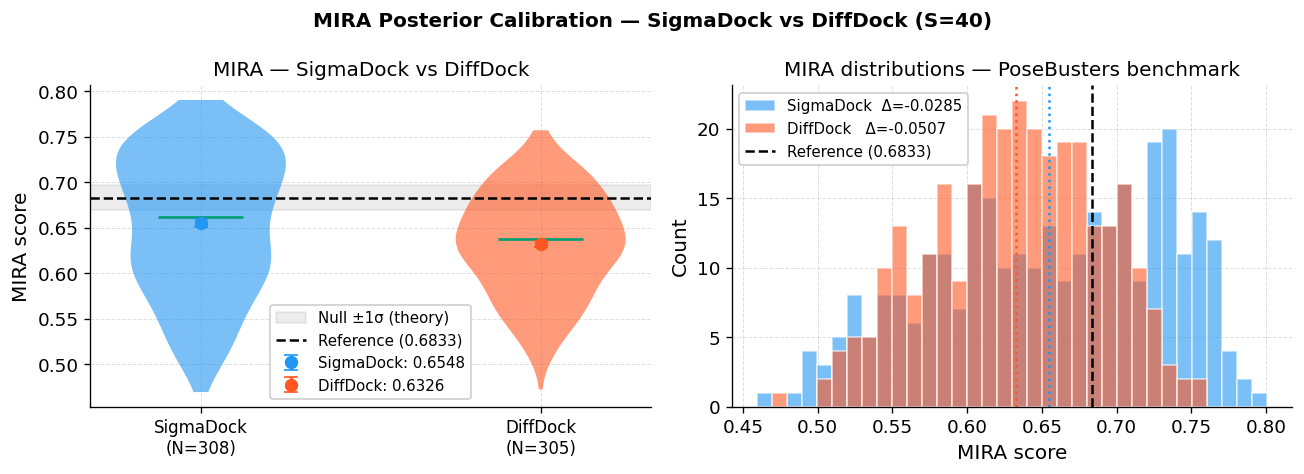

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: side-by-side violin ─────────────────────────────────────────────────
ax = axes[0]
datasets = [
    (sd_mira_scores, SD_C, f'SigmaDock\n(N={len(sd_mira_scores)})'),
    (dd_mira_scores, DD_C, f'DiffDock\n(N={len(dd_mira_scores)})'),
]
vp = ax.violinplot([d for d, _, _ in datasets], positions=[0, 1],
                   showmedians=True, showextrema=False)
for body, (_, color, _) in zip(vp['bodies'], datasets):
    body.set_facecolor(color); body.set_alpha(0.6)
for i, (scores, color, label) in enumerate(datasets):
    se = bootstrap_mira(scores)['std']
    ax.errorbar(i, scores.mean(), yerr=se, fmt='o', color=color,
                capsize=4, ms=7, zorder=5, label=f'{label.split(chr(10))[0]}: {scores.mean():.4f}')
_L_ref = min(len(sd_mira_scores), len(dd_mira_scores))
_sigma_null = np.sqrt(1 / (18 * _L_ref))
ax.axhspan(MIRA_REF - _sigma_null, MIRA_REF + _sigma_null,
           alpha=0.15, color='grey', zorder=0, label=f'Null ±1σ (theory)')
ax.axhline(MIRA_REF, color='k', lw=1.5, ls='--', label=f'Reference ({MIRA_REF:.4f})')
ax.set_xticks([0, 1])
ax.set_xticklabels([lbl for _, _, lbl in datasets], fontsize=10)
ax.set_ylabel('MIRA score')
ax.set_title('MIRA — SigmaDock vs DiffDock')
ax.legend(fontsize=9)

# ── Right: overlapping histograms ────────────────────────────────────────────
ax = axes[1]
bins = np.linspace(
    min(sd_mira_scores.min(), dd_mira_scores.min()) - 0.01,
    max(sd_mira_scores.max(), dd_mira_scores.max()) + 0.01,
    35,
)
ax.hist(sd_mira_scores, bins=bins, color=SD_C, alpha=0.6, edgecolor='white',
        label=f'SigmaDock  Δ={sd_mira_scores.mean()-MIRA_REF:+.4f}')
ax.hist(dd_mira_scores, bins=bins, color=DD_C, alpha=0.6, edgecolor='white',
        label=f'DiffDock   Δ={dd_mira_scores.mean()-MIRA_REF:+.4f}')
ax.axvline(MIRA_REF, color='k', lw=1.5, ls='--',
           label=f'Reference ({MIRA_REF:.4f})')
ax.axvline(sd_mira_scores.mean(), color=SD_C, lw=1.5, ls=':')
ax.axvline(dd_mira_scores.mean(), color=DD_C, lw=1.5, ls=':')
ax.set_xlabel('MIRA score')
ax.set_ylabel('Count')
ax.set_title('MIRA distributions — PoseBusters benchmark')
ax.legend(fontsize=9)

fig.suptitle('MIRA Posterior Calibration — SigmaDock vs DiffDock (S=40)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/mira_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Per-Group TARP & MIRA

Breaks down calibration **separately** for each geometric degree of freedom:
- **Translation** (R³): where does the ligand centroid land relative to the binding site?
- **Rotation** (SO(3)): how is the ligand oriented?
- **Torsion** (T^k): what are the internal dihedral angles?

Prior distributions match DiffDock's randomize_position at t=1 (used as the TARP/MIRA reference):
- Translation: N(Cα_COM, σ²I) with σ = std_ca × 1.46 / 1.73
- Rotation: Haar-uniform on SO(3)
- Torsion: Uniform([−π, π])^k independent per bond

Data computed by `scripts/group_eval.py` — submit via `sbatch ~/slurm/sigmadock/group_eval.sh`.

In [10]:
# ── Per-group constants ────────────────────────────────────────────────────────
GROUPS     = ['translation', 'rotation', 'torsion']
COLORS     = {'translation': 'C0', 'rotation': 'C1', 'torsion': 'C2'}
LABELS     = {'translation': 'Translation (R³)', 'rotation': 'Rotation (SO(3))',
               'torsion': 'Torsion (T^k)'}
dist_keys  = ['translation', 'rotation', 'torsion_rms']
dist_labels = {
    'translation': 'Translation (Å)',
    'rotation':    'Rotation (rad)',
    'torsion_rms': 'Torsion RMS (rad)',
}

SD_GE = f'{SD_RESULTS}/group_eval'
DD_GE = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics/group_eval'


def _npy(path, allow_pickle=False):
    """Load .npy returning None if file doesn't exist."""
    if os.path.exists(path):
        return np.load(path, allow_pickle=allow_pickle)
    print(f'  [missing] {path}')
    return None


# ── SigmaDock group_eval ──────────────────────────────────────────────────────
sd_ge_names = _npy(f'{SD_GE}/complex_names.npy', allow_pickle=True)
sd_nrot     = _npy(f'{SD_GE}/n_rot_bonds.npy')
sd_tarp, sd_mira, sd_dist = {}, {}, {}
for _g in GROUPS:
    sd_tarp[_g] = _npy(f'{SD_GE}/tarp_fractions_{_g}.npy')
    sd_mira[_g] = {
        'names':  _npy(f'{SD_GE}/mira_names_{_g}.npy',  allow_pickle=True),
        'scores': _npy(f'{SD_GE}/mira_scores_{_g}.npy'),
    }
for _k in dist_keys:
    sd_dist[_k] = _npy(f'{SD_GE}/distances_{_k}.npy')

# ── DiffDock group_eval (PoseBusters) ─────────────────────────────────────────
dd_ge_names = _npy(f'{DD_GE}/complex_names.npy', allow_pickle=True)
dd_tarp, dd_mira = {}, {}
for _g in GROUPS:
    dd_tarp[_g] = _npy(f'{DD_GE}/tarp_fractions_{_g}.npy')
    dd_mira[_g] = {
        'names':  _npy(f'{DD_GE}/mira_names_{_g}.npy',  allow_pickle=True),
        'scores': _npy(f'{DD_GE}/mira_scores_{_g}.npy'),
    }

if sd_ge_names is not None:
    print(f'SigmaDock  group_eval: {len(sd_ge_names)} complexes')
else:
    print('SigmaDock group_eval not yet computed.')
    print('  Run:  sbatch ~/slurm/sigmadock/group_eval.sh')
    print(f'  Or:   python scripts/group_eval.py {SD_RESULTS} '
          '--data-dir /home/qf226/rds/hpc-work/data/posebusters_benchmark_set')

if dd_ge_names is not None:
    print(f'DiffDock   group_eval: {len(dd_ge_names)} complexes')

SigmaDock  group_eval: 308 complexes
DiffDock   group_eval: 305 complexes


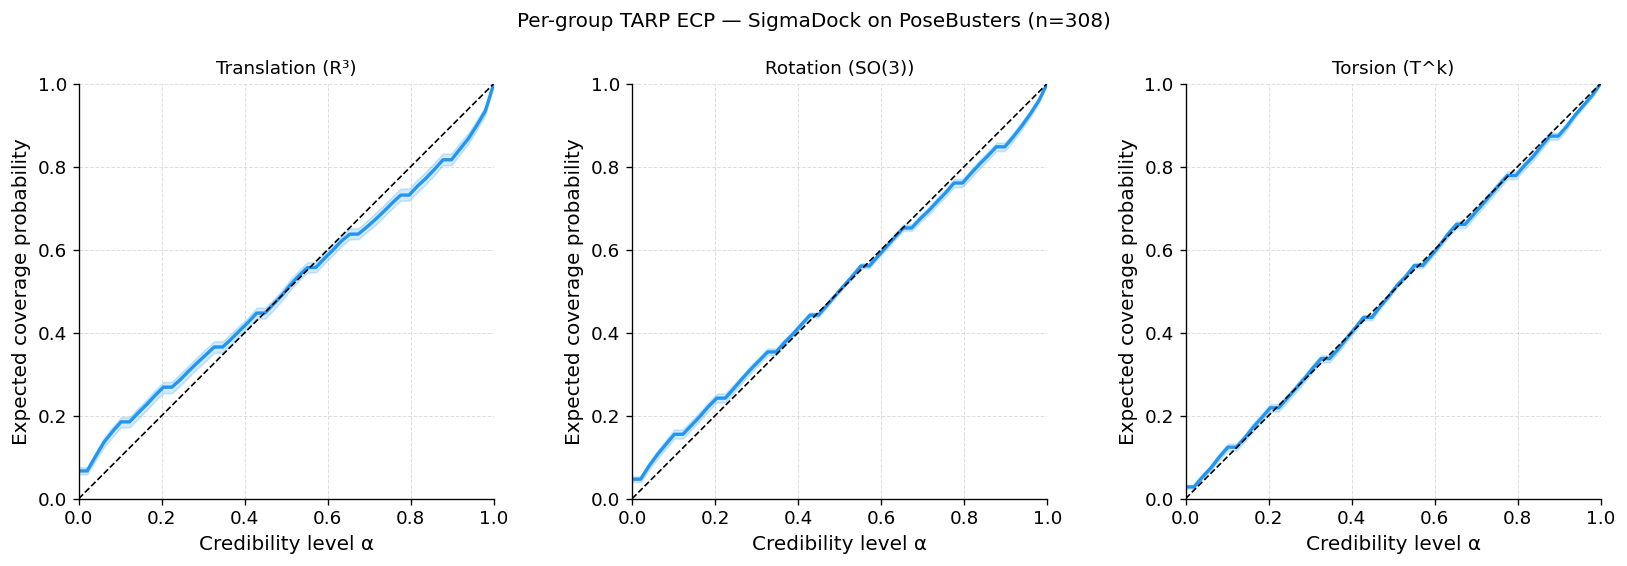

In [11]:
# 6a: Per-group TARP ECP — SigmaDock (3 panels)
if sd_ge_names is not None and all(sd_tarp[g] is not None for g in GROUPS):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        f = sd_tarp[g]
        ecp, alpha = ecp_from_fractions(f)
        boot = bootstrap_ecp(f, n_bootstrap=300)
        n_valid = int(np.any(np.isfinite(f), axis=1).sum())
        plot_ecp(ecp, alpha, ax=ax,
                 label=f'SigmaDock (n={n_valid})',
                 color=SD_C, bootstrap_ecps=boot)
        ax.set_title(LABELS[g], fontsize=11)
    fig.suptitle(
        f'Per-group TARP ECP — SigmaDock on PoseBusters (n={len(sd_ge_names)})',
        fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/group_tarp_ecp_sigmadock.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SigmaDock group_eval data not yet available — run cell 6·Setup first.')

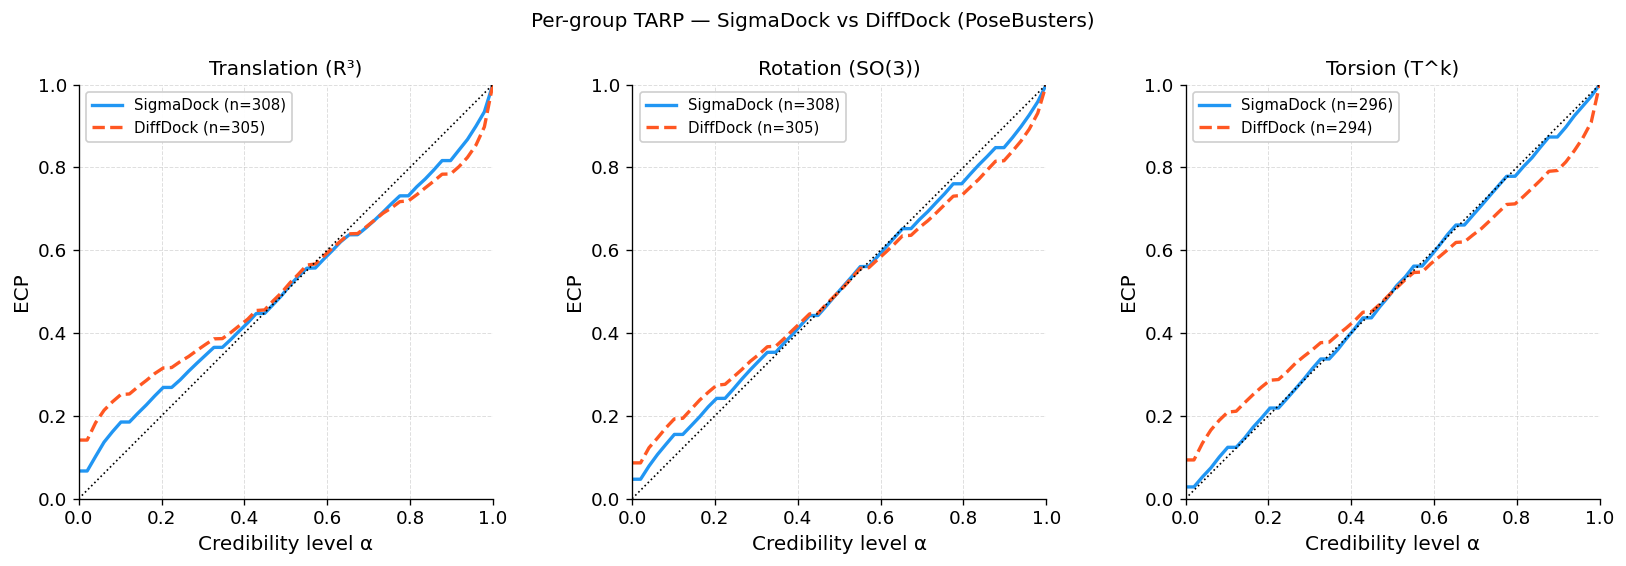

In [12]:
# 6b: Per-group TARP overlay — SigmaDock vs DiffDock
_both = (
    sd_ge_names is not None and all(sd_tarp[g] is not None for g in GROUPS) and
    dd_ge_names is not None and all(dd_tarp[g] is not None for g in GROUPS)
)
if _both:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        for name, f, col, ls in [
            ('SigmaDock', sd_tarp[g], SD_C, '-'),
            ('DiffDock',  dd_tarp[g], DD_C, '--'),
        ]:
            n_valid = int(np.any(np.isfinite(f), axis=1).sum())
            ecp, alpha = ecp_from_fractions(f)
            ax.plot(alpha, ecp, color=col, ls=ls, lw=2,
                    label=f'{name} (n={n_valid})')
        ax.plot([0, 1], [0, 1], 'k:', lw=1)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
        ax.set_xlabel('Credibility level α')
        ax.set_ylabel('ECP')
        ax.set_title(LABELS[g])
        ax.legend(fontsize=9)
    fig.suptitle('Per-group TARP — SigmaDock vs DiffDock (PoseBusters)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/group_tarp_ecp_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
elif sd_ge_names is None:
    print('SigmaDock group_eval data not yet available.')
elif dd_ge_names is None:
    print('DiffDock group_eval data not available at expected path.')

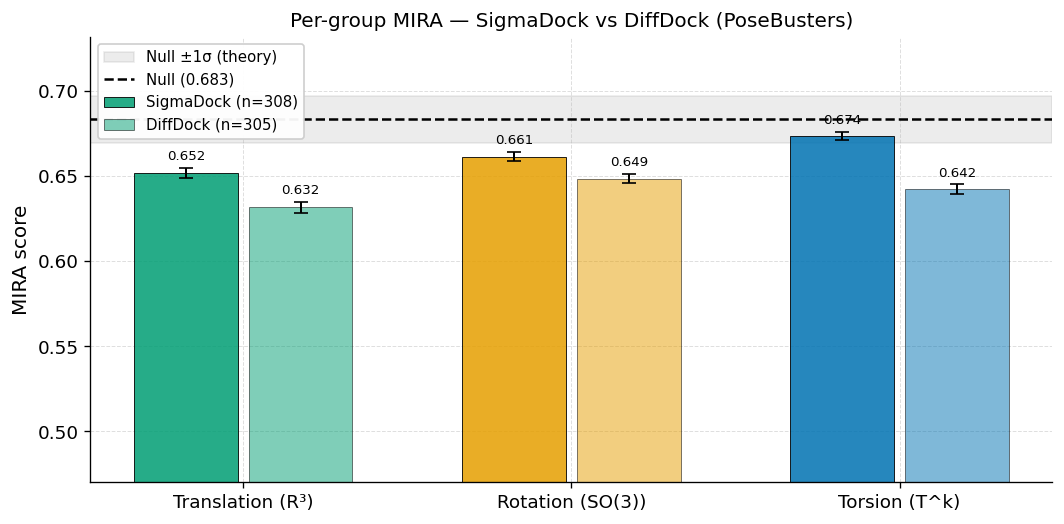


Group                                   SigmaDock                    DiffDock      Null
----------------------------------------------------------------------------------------
Translation (R³)          0.6520 ± 0.0030 (n=308)     0.6315 ± 0.0033 (n=305)    0.6833
Rotation (SO(3))          0.6614 ± 0.0027 (n=308)     0.6485 ± 0.0028 (n=305)    0.6833
Torsion (T^k)             0.6735 ± 0.0023 (n=296)     0.6423 ± 0.0027 (n=294)    0.6833
(null = 0.6833;  < null → mode-collapsed,  > null → over-dispersed)


In [13]:
# 6c: Per-group MIRA bar chart — SigmaDock vs DiffDock
_sd_mira_ready = all(sd_mira[g]['scores'] is not None for g in GROUPS)
_dd_mira_ready = all(dd_mira[g]['scores'] is not None for g in GROUPS)

if _sd_mira_ready:
    _x = np.arange(len(GROUPS))
    _w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for j, (name, gm, col, alpha_bar) in enumerate([
        ('SigmaDock', sd_mira, SD_C, 0.85),
        ('DiffDock',  dd_mira, DD_C, 0.5),
    ]):
        if name == 'DiffDock' and not _dd_mira_ready:
            continue
        for i, g in enumerate(GROUPS):
            s = gm[g]['scores']
            if s is None or len(s) == 0:
                continue
            offset = -_w / 2 if j == 0 else _w / 2
            m  = float(s.mean())
            se = float(bootstrap_mira(s)['std'])
            ax.bar(_x[i] + offset, m, width=_w * 0.9,
                   color=COLORS[g], alpha=alpha_bar, edgecolor='k', linewidth=0.6,
                   label=f'{name} (n={len(s)})' if i == 0 else None)
            ax.errorbar(_x[i] + offset, m, yerr=se,
                        fmt='none', color='k', capsize=4, lw=1.2)
            ax.text(_x[i] + offset, m + se + 0.003, f'{m:.3f}',
                    ha='center', va='bottom', fontsize=8)

    _L_ref = min(len(sd_mira[g]['scores']) for g in GROUPS
                    if sd_mira[g]['scores'] is not None and len(sd_mira[g]['scores']) > 0)
    _sigma_null = np.sqrt(1 / (18 * _L_ref))
    ax.axhspan(MIRA_REF - _sigma_null, MIRA_REF + _sigma_null,
               alpha=0.15, color='grey', zorder=0, label=f'Null ±1σ (theory)')
    ax.axhline(MIRA_REF, color='k', ls='--', lw=1.5,
               label=f'Null ({MIRA_REF:.3f})')
    ax.set_xticks(_x)
    ax.set_xticklabels([LABELS[g] for g in GROUPS], fontsize=11)
    ax.set_ylabel('MIRA score')
    ax.set_title('Per-group MIRA — SigmaDock vs DiffDock (PoseBusters)', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0.47)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/group_mira_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n{"Group":<22} {"SigmaDock":>26}  {"DiffDock":>26}  {"Null":>8}')
    print('-' * 88)
    for g in GROUPS:
        sd_s = sd_mira[g]['scores']
        dd_s = dd_mira[g]['scores'] if _dd_mira_ready else None
        sd_str = (f'{sd_s.mean():.4f} ± {bootstrap_mira(sd_s)["std"]:.4f} (n={len(sd_s)})'
                  if sd_s is not None and len(sd_s) else '(missing)')
        dd_str = (f'{dd_s.mean():.4f} ± {bootstrap_mira(dd_s)["std"]:.4f} (n={len(dd_s)})'
                  if dd_s is not None and len(dd_s) else '(missing)')
        print(f'{LABELS[g]:<22} {sd_str:>26}  {dd_str:>26}  {MIRA_REF:>8.4f}')
    print(f'(null = {MIRA_REF:.4f};  < null → mode-collapsed,  > null → over-dispersed)')
else:
    print('SigmaDock group_eval data not yet available — run cell 6·Setup first.')

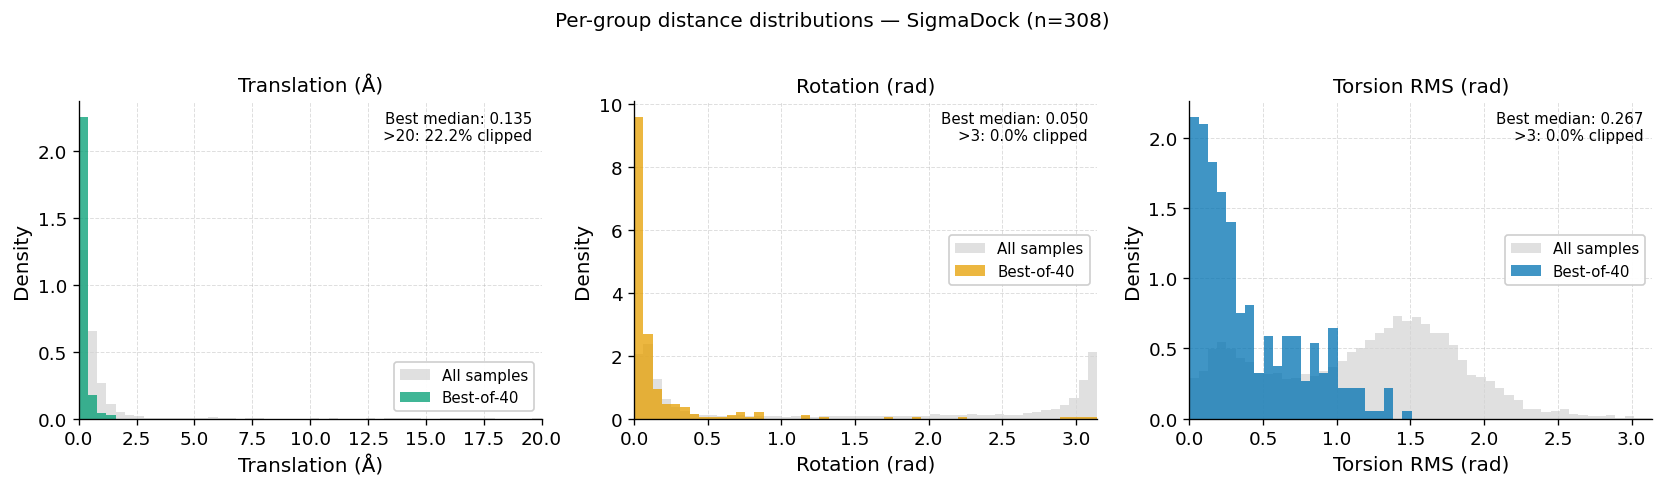

In [14]:
# 6d: Per-group distance distributions — SigmaDock (best-of-S vs all samples)
_dist_xlims = {'translation': 20.0, 'rotation': np.pi, 'torsion_rms': np.pi}

if sd_ge_names is not None and all(sd_dist[k] is not None for k in dist_keys):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key in zip(axes, dist_keys):
        D    = sd_dist[key]          # (N, S)
        xlim = _dist_xlims[key]
        best = np.nanmin(D, axis=1)
        flat = D.flatten()
        flat = flat[np.isfinite(flat)]
        bins = np.linspace(0, xlim, 51)
        col  = COLORS['torsion'] if key == 'torsion_rms' else COLORS[key]
        ax.hist(flat, bins=bins, color='lightgray', density=True,
                label='All samples', alpha=0.7)
        ax.hist(best, bins=bins, color=col, density=True, alpha=0.75,
                label=f'Best-of-{D.shape[1]}')
        ax.set_xlim(0, xlim)
        ax.set_xlabel(dist_labels[key])
        ax.set_ylabel('Density')
        ax.set_title(dist_labels[key])
        ax.legend(fontsize=9)
        pct_clip = (flat > xlim).mean() * 100
        ax.text(0.98, 0.97,
                f'Best median: {np.nanmedian(best):.3f}\n>{xlim:.0f}: {pct_clip:.1f}% clipped',
                transform=ax.transAxes, ha='right', va='top', fontsize=9)
    fig.suptitle(f'Per-group distance distributions — SigmaDock (n={len(sd_ge_names)})',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/group_distances_hist.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SigmaDock group distance data not yet available.')

## 7. Summary

In [15]:
def calibration_label(dev):
    if abs(dev) < 0.005: return 'well-calibrated'
    return 'mode-collapsed' if dev < 0 else 'over-dispersed'

print(f"{'':22s} {'SigmaDock':>12s} {'DiffDock':>12s} {'Reference':>12s}")
print('-' * 60)
print(f"{'N complexes':22s} {len(sd_mira_scores):>12d} {len(dd_mira_scores):>12d} {'—':>12s}")
print(f"{'MIRA mean':22s} {sd_mira_scores.mean():>12.4f} {dd_mira_scores.mean():>12.4f} {MIRA_REF:>12.4f}")
sd_dev = sd_mira_scores.mean() - MIRA_REF
dd_dev = dd_mira_scores.mean() - MIRA_REF
print(f"{'MIRA deviation':22s} {sd_dev:>+12.4f} {dd_dev:>+12.4f} {'0.0000':>12s}")
print(f"{'Calibration':22s} {calibration_label(sd_dev):>12s} {calibration_label(dd_dev):>12s} {'perfect':>12s}")

print()
print('TARP (centroid, K=100):')
print(f"  SigmaDock ECP at α=0.5: {np.interp(0.5, sd_alpha_c, sd_ecp_c):.3f}")
print(f"  DiffDock  ECP at α=0.5: {np.interp(0.5, dd_alpha_c, dd_ecp_c):.3f}")
print(f"  (perfect = 0.500)")

if sd_tarp_rmsd is not None:
    print()
    print(f'TARP (RMSD, SD K={sd_tarp_rmsd.shape[1]}, DD K={dd_tarp_rmsd.shape[1]}):')
    print(f"  SigmaDock ECP at α=0.5: {np.interp(0.5, sd_alpha_r, sd_ecp_r):.3f}")
    print(f"  DiffDock  ECP at α=0.5: {np.interp(0.5, dd_alpha_r, dd_ecp_r):.3f}")

                          SigmaDock     DiffDock    Reference
------------------------------------------------------------
N complexes                     308          305            —
MIRA mean                    0.6548       0.6326       0.6833
MIRA deviation              -0.0285      -0.0507       0.0000
Calibration            mode-collapsed mode-collapsed      perfect

TARP (centroid, K=100):
  SigmaDock ECP at α=0.5: 0.502
  DiffDock  ECP at α=0.5: 0.506
  (perfect = 0.500)

TARP (RMSD, SD K=10, DD K=10):
  SigmaDock ECP at α=0.5: 0.500
  DiffDock  ECP at α=0.5: 0.501
